<a href="https://colab.research.google.com/github/XH-DP3/MedDatathon-2026/blob/main/datathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from scipy.stats import lognorm, loguniform, randint

from sklearn.compose import make_column_transformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.feature_selection import RFECV

import warnings
# Add this to ignore the specific UserWarning from scikit-learn
warnings.filterwarnings("ignore", category=UserWarning,
                        message="X does not have valid feature names")

# **Loaded Dataset**

In [3]:
heart_disease_df = pd.read_csv('heart_disease_uci.csv')
heart_disease_df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [4]:
heart_disease_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
heart_disease_df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [6]:
# Split the dataset into the training and the testing set
df_train, df_test = train_test_split(heart_disease_df,train_size = 0.7,
                                     random_state = 123)
df_train.shape

(644, 16)

**Feature Engineering**

In [7]:
df_train["risk_score"] = df_train["chol"] + df_train["trestbps"]
df_test["risk_score"] = df_test["chol"] + df_test["trestbps"]

In [8]:
df_train["cardiac_stress"] = df_train["trestbps"] * df_train["thalch"]
df_test["cardiac_stress"] = df_test["trestbps"] * df_test["thalch"]

**Splitting data**

In [9]:
# Split dataset into features and target
X_train, y_train = (
    df_train.drop(columns=["num"]),
    df_train["num"],
)
X_test, y_test = (
    df_test.drop(columns=["num"]),
    df_test["num"],
)

In [10]:
numeric_features = [
    'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'cardiac_stress', 'risk_score'
]
categorical_features = [
    'dataset', 'cp', 'restecg', 'slope', 'ca', 'thal'
]

binary_features = [
    'sex', 'fbs', 'exang',
]

drop_features = [
    'id',
]

numeric_transformer = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler())

categorical_transformer = make_pipeline(
    (SimpleImputer(strategy='most_frequent')),
    (OneHotEncoder(handle_unknown='ignore')))

binary_transformer = make_pipeline(
    (SimpleImputer(strategy='most_frequent')),
    OneHotEncoder(drop="if_binary", dtype=int))

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (categorical_transformer, categorical_features),
    (binary_transformer, binary_features),
    ("drop", drop_features),
)

print(preprocessor)

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak', 'cardiac_stress', 'risk_score']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['dataset', 'cp', 'restecg', 'slope', 'ca',
                                  'thal']),
                                ('pipeline

In [11]:
# Fit the model
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['age', 'trestbps', 'chol', 'thalch',
                                  'oldpeak', 'cardiac_stress', 'risk_score']),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['dataset', 'cp', 'restecg', 'slope', 'ca',
                                  'thal']),
                                ('pipeline-3',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                dtype=<class 'int'>))]),
                                 ['sex', 'fbs', 'exang']),
                                ('drop', 'drop', ['id'])])

In [12]:
feature_names = preprocessor.get_feature_names_out()
feature_names

array(['pipeline-1__age', 'pipeline-1__trestbps', 'pipeline-1__chol',
       'pipeline-1__thalch', 'pipeline-1__oldpeak',
       'pipeline-1__cardiac_stress', 'pipeline-1__risk_score',
       'pipeline-2__dataset_Cleveland', 'pipeline-2__dataset_Hungary',
       'pipeline-2__dataset_Switzerland',
       'pipeline-2__dataset_VA Long Beach', 'pipeline-2__cp_asymptomatic',
       'pipeline-2__cp_atypical angina', 'pipeline-2__cp_non-anginal',
       'pipeline-2__cp_typical angina',
       'pipeline-2__restecg_lv hypertrophy', 'pipeline-2__restecg_normal',
       'pipeline-2__restecg_st-t abnormality',
       'pipeline-2__slope_downsloping', 'pipeline-2__slope_flat',
       'pipeline-2__slope_upsloping', 'pipeline-2__ca_0.0',
       'pipeline-2__ca_1.0', 'pipeline-2__ca_2.0', 'pipeline-2__ca_3.0',
       'pipeline-2__thal_fixed defect', 'pipeline-2__thal_normal',
       'pipeline-2__thal_reversable defect', 'pipeline-3__sex_Male',
       'pipeline-3__fbs_True', 'pipeline-3__exang_True'], d

In [13]:
def remap_num(value):
    if value == 0:
        return 0
    elif value == 1:
        return 1
    else:
        return 2  # Represents 2, 3, and 4

y_train = y_train.apply(remap_num)
y_test = y_test.apply(remap_num)

print(y_train.value_counts())
print(y_test.value_counts())

num
0    281
1    185
2    178
Name: count, dtype: int64
num
0    130
1     80
2     66
Name: count, dtype: int64


In [14]:
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs,
                            scoring=scoring, return_train_score = True)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

In [15]:
# Build a baseline model with DummyClassifier
dummy = DummyClassifier(strategy="stratified")     # Use strategy="stratified" to handle class imbalance

In [16]:
# Evaluate the DummyClassifier baseline model using cross-validation
scores = {}
scoring = ["accuracy", "recall_weighted", "f1_macro"]
dummy_pipe = make_pipeline(preprocessor, dummy)
scores["dummy"] = mean_std_cross_val_scores(dummy_pipe, X_train, y_train)
pd.DataFrame(scores).T

,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)


Linear model

In [17]:
pipe_lr = make_pipeline(preprocessor, LogisticRegression(max_iter=1000, class_weight="balanced", random_state = 123))
scores["lr"] = mean_std_cross_val_scores(pipe_lr, X_train, y_train)
pd.DataFrame(scores).T

,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)


Non-linear models

In [18]:
models = {
    "xgboost": XGBClassifier(
        random_state=123,
        verbosity=0
    ),
    "RF": RandomForestClassifier(
        n_jobs=-1,
        random_state=123,
        class_weight="balanced"
    ),
    "lgbm": LGBMClassifier(
        random_state=123,
        verbose=-1,
        class_weight="balanced"
    )
}

In [19]:
for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    scores[name] = mean_std_cross_val_scores(pipe, X_train, y_train)
pd.DataFrame(scores).T

,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)
xgboost,0.216 (+/- 0.035),0.022 (+/- 0.001),0.674 (+/- 0.037),1.000 (+/- 0.000),0.674 (+/- 0.037),1.000 (+/- 0.000),0.648 (+/- 0.041),1.000 (+/- 0.000)
RF,0.288 (+/- 0.001),0.056 (+/- 0.004),0.686 (+/- 0.038),1.000 (+/- 0.000),0.686 (+/- 0.038),1.000 (+/- 0.000),0.650 (+/- 0.041),1.000 (+/- 0.000)
lgbm,0.160 (+/- 0.033),0.023 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.637 (+/- 0.040),1.000 (+/- 0.001)


**feature selection**

lr_tuned

In [20]:
param_dist = {
    'logisticregression__C': loguniform(1e-3, 1e3)
}

random_search_lr = RandomizedSearchCV(pipe_lr,
                                      param_distributions = param_dist,
                                      n_iter = 100,
                                      random_state = 123,
                                      refit = "f1_macro",
                                      scoring = scoring,
                                      return_train_score = True)

random_search_lr.fit(X_train, y_train)

print("Best Hyperparameter:", random_search_lr.best_params_)
print("Best score:", random_search_lr.best_score_)

relevant = [
    "param_logisticregression__C",
    "mean_test_recall_weighted",
    "std_test_recall_weighted",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "mean_train_recall_weighted",
    "std_train_recall_weighted",
    "mean_train_accuracy",
    "std_train_accuracy",
    "mean_train_f1_macro",
    "std_train_f1_macro",
    "mean_fit_time",
    "rank_test_recall_weighted",
]
pd.DataFrame(random_search_lr.cv_results_)[relevant].set_index("rank_test_recall_weighted").sort_index().T
scores["lr_tuned"] = mean_std_cross_val_scores(random_search_lr.best_estimator_, X_train, y_train)
pd.DataFrame(scores).T

Best Hyperparameter: {'logisticregression__C': np.float64(0.03182234592129467)}
Best score: 0.6544502045715387


,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)
xgboost,0.216 (+/- 0.035),0.022 (+/- 0.001),0.674 (+/- 0.037),1.000 (+/- 0.000),0.674 (+/- 0.037),1.000 (+/- 0.000),0.648 (+/- 0.041),1.000 (+/- 0.000)
RF,0.288 (+/- 0.001),0.056 (+/- 0.004),0.686 (+/- 0.038),1.000 (+/- 0.000),0.686 (+/- 0.038),1.000 (+/- 0.000),0.650 (+/- 0.041),1.000 (+/- 0.000)
lgbm,0.160 (+/- 0.033),0.023 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.637 (+/- 0.040),1.000 (+/- 0.001)
lr_tuned,0.039 (+/- 0.005),0.023 (+/- 0.002),0.685 (+/- 0.051),0.708 (+/- 0.017),0.685 (+/- 0.051),0.708 (+/- 0.017),0.654 (+/- 0.044),0.684 (+/- 0.017)


RF_tuned

In [21]:
param_dist = {"randomforestclassifier__max_depth": randint(3, 15),
              "randomforestclassifier__n_estimators": randint(10, 500),
              'randomforestclassifier__min_samples_split': randint(2, 30),
              'randomforestclassifier__min_samples_leaf': randint(1, 20)
              }
random_search_rf = RandomizedSearchCV(make_pipeline(preprocessor, models["RF"]),
                  param_distributions = param_dist,
                  n_iter=50,
                  n_jobs=-1,
                  random_state = 123,
                  scoring = scoring,
                  refit = "f1_macro",
                  return_train_score=True)
random_search_rf.fit(X_train, y_train)
best_hyper = random_search_rf.best_params_
best_score = random_search_rf.best_score_
print("Best hyperparameter: ", best_hyper)
print("Best score: ", best_score)

relevant = [
    "mean_test_recall_weighted",
    "std_test_recall_weighted",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "mean_train_recall_weighted",
    "std_train_recall_weighted",
    "mean_train_accuracy",
    "std_train_accuracy",
    "mean_train_f1_macro",
    "std_train_f1_macro",
    "param_randomforestclassifier__max_depth",
    "param_randomforestclassifier__n_estimators",
    "param_randomforestclassifier__min_samples_split",
    "param_randomforestclassifier__min_samples_leaf",
    "mean_fit_time",
    "rank_test_recall_weighted",
]
pd.DataFrame(random_search_rf.cv_results_)[relevant].set_index("rank_test_recall_weighted").sort_index().T
scores["rf_tuned"] = mean_std_cross_val_scores(random_search_rf.best_estimator_, X_train, y_train)
pd.DataFrame(scores).T

Best hyperparameter:  {'randomforestclassifier__max_depth': 11, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 27}
Best score:  0.6586610262915122


,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)
xgboost,0.216 (+/- 0.035),0.022 (+/- 0.001),0.674 (+/- 0.037),1.000 (+/- 0.000),0.674 (+/- 0.037),1.000 (+/- 0.000),0.648 (+/- 0.041),1.000 (+/- 0.000)
RF,0.288 (+/- 0.001),0.056 (+/- 0.004),0.686 (+/- 0.038),1.000 (+/- 0.000),0.686 (+/- 0.038),1.000 (+/- 0.000),0.650 (+/- 0.041),1.000 (+/- 0.000)
lgbm,0.160 (+/- 0.033),0.023 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.637 (+/- 0.040),1.000 (+/- 0.001)
lr_tuned,0.039 (+/- 0.005),0.023 (+/- 0.002),0.685 (+/- 0.051),0.708 (+/- 0.017),0.685 (+/- 0.051),0.708 (+/- 0.017),0.654 (+/- 0.044),0.684 (+/- 0.017)
rf_tuned,0.095 (+/- 0.004),0.033 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.659 (+/- 0.047),0.927 (+/- 0.005)


lgbm_tuned

In [22]:
param_dist = {"lgbmclassifier__learning_rate": [0.01, 0.3],
              "lgbmclassifier__n_estimators": randint(10, 500),
              "lgbmclassifier__max_depth": randint(3, 15),
              "lgbmclassifier__num_leaves": randint(20, 100)}
random_search_lgbm = RandomizedSearchCV(make_pipeline(preprocessor, models["lgbm"]),
                  param_distributions = param_dist,
                  n_iter=50,
                  n_jobs=-1,
                  random_state = 123,
                  scoring = scoring,
                  refit = "f1_macro",
                  return_train_score=True)
random_search_lgbm.fit(X_train, y_train)
best_hyper = random_search_lgbm.best_params_
best_score = random_search_lgbm.best_score_
print("Best hyperparameter: ", best_hyper)
print("Best score: ", best_score)

relevant = [
    "mean_test_recall_weighted",
    "std_test_recall_weighted",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "mean_train_recall_weighted",
    "std_train_recall_weighted",
    "mean_train_accuracy",
    "std_train_accuracy",
    "mean_train_f1_macro",
    "std_train_f1_macro",
    "param_lgbmclassifier__learning_rate",
    "param_lgbmclassifier__n_estimators",
    "param_lgbmclassifier__max_depth",
    "param_lgbmclassifier__num_leaves",
    "mean_fit_time",
    "rank_test_recall_weighted",
]
pd.DataFrame(random_search_lgbm.cv_results_)[relevant].set_index("rank_test_recall_weighted").sort_index().T
scores["lgbm_tuned"] = mean_std_cross_val_scores(random_search_lgbm.best_estimator_, X_train, y_train)
pd.DataFrame(scores).T

Best hyperparameter:  {'lgbmclassifier__learning_rate': 0.01, 'lgbmclassifier__max_depth': 7, 'lgbmclassifier__n_estimators': 260, 'lgbmclassifier__num_leaves': 83}
Best score:  0.6604369835120972


,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)
xgboost,0.216 (+/- 0.035),0.022 (+/- 0.001),0.674 (+/- 0.037),1.000 (+/- 0.000),0.674 (+/- 0.037),1.000 (+/- 0.000),0.648 (+/- 0.041),1.000 (+/- 0.000)
RF,0.288 (+/- 0.001),0.056 (+/- 0.004),0.686 (+/- 0.038),1.000 (+/- 0.000),0.686 (+/- 0.038),1.000 (+/- 0.000),0.650 (+/- 0.041),1.000 (+/- 0.000)
lgbm,0.160 (+/- 0.033),0.023 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.637 (+/- 0.040),1.000 (+/- 0.001)
lr_tuned,0.039 (+/- 0.005),0.023 (+/- 0.002),0.685 (+/- 0.051),0.708 (+/- 0.017),0.685 (+/- 0.051),0.708 (+/- 0.017),0.654 (+/- 0.044),0.684 (+/- 0.017)
rf_tuned,0.095 (+/- 0.004),0.033 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.659 (+/- 0.047),0.927 (+/- 0.005)
lgbm_tuned,0.326 (+/- 0.030),0.027 (+/- 0.003),0.686 (+/- 0.054),0.893 (+/- 0.004),0.686 (+/- 0.054),0.893 (+/- 0.004),0.660 (+/- 0.061),0.889 (+/- 0.005)


xgboost_tuned

In [23]:
param_dist = {'xgbclassifier__n_estimators': randint(100, 700),
              'xgbclassifier__max_depth': randint(3, 10),
              'xgbclassifier__learning_rate': loguniform(0.01, 0.3)}
random_search_xgb = RandomizedSearchCV(make_pipeline(preprocessor, models["xgboost"]),
                  param_distributions = param_dist,
                  n_iter=50,
                  n_jobs=-1,
                  random_state = 123,
                  scoring = scoring,
                  refit = "f1_macro",
                  return_train_score=True)
random_search_xgb.fit(X_train, y_train)
best_hyper = random_search_xgb.best_params_
best_score = random_search_xgb.best_score_
print("Best hyperparameter: ", best_hyper)
print("Best score: ", best_score)

Best hyperparameter:  {'xgbclassifier__learning_rate': np.float64(0.0472794108376973), 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 103}
Best score:  0.6511895108100803


In [24]:
relevant = [
    "mean_test_recall_weighted",
    "std_test_recall_weighted",
    "mean_test_accuracy",
    "std_test_accuracy",
    "mean_test_f1_macro",
    "std_test_f1_macro",
    "mean_train_recall_weighted",
    "std_train_recall_weighted",
    "mean_train_accuracy",
    "std_train_accuracy",
    "mean_train_f1_macro",
    "std_train_f1_macro",
    "param_xgbclassifier__n_estimators",
    "param_xgbclassifier__max_depth",
    "param_xgbclassifier__learning_rate",
    "mean_fit_time",
    "rank_test_f1_macro",
]
pd.DataFrame(random_search_xgb.cv_results_)[relevant].set_index("rank_test_f1_macro").sort_index().T
scores["xgboost_tuned"] = mean_std_cross_val_scores(random_search_xgb.best_estimator_, X_train, y_train)
pd.DataFrame(scores).T

,fit_time,score_time,test_accuracy,train_accuracy,test_recall_weighted,train_recall_weighted,test_f1_macro,train_f1_macro
dummy,0.020 (+/- 0.002),0.018 (+/- 0.002),0.363 (+/- 0.049),0.365 (+/- 0.021),0.363 (+/- 0.049),0.365 (+/- 0.021),0.343 (+/- 0.048),0.347 (+/- 0.020)
lr,0.061 (+/- 0.006),0.027 (+/- 0.008),0.663 (+/- 0.031),0.740 (+/- 0.015),0.663 (+/- 0.031),0.740 (+/- 0.015),0.639 (+/- 0.026),0.722 (+/- 0.019)
xgboost,0.216 (+/- 0.035),0.022 (+/- 0.001),0.674 (+/- 0.037),1.000 (+/- 0.000),0.674 (+/- 0.037),1.000 (+/- 0.000),0.648 (+/- 0.041),1.000 (+/- 0.000)
RF,0.288 (+/- 0.001),0.056 (+/- 0.004),0.686 (+/- 0.038),1.000 (+/- 0.000),0.686 (+/- 0.038),1.000 (+/- 0.000),0.650 (+/- 0.041),1.000 (+/- 0.000)
lgbm,0.160 (+/- 0.033),0.023 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.661 (+/- 0.038),1.000 (+/- 0.001),0.637 (+/- 0.040),1.000 (+/- 0.001)
lr_tuned,0.039 (+/- 0.005),0.023 (+/- 0.002),0.685 (+/- 0.051),0.708 (+/- 0.017),0.685 (+/- 0.051),0.708 (+/- 0.017),0.654 (+/- 0.044),0.684 (+/- 0.017)
rf_tuned,0.095 (+/- 0.004),0.033 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.688 (+/- 0.044),0.929 (+/- 0.004),0.659 (+/- 0.047),0.927 (+/- 0.005)
lgbm_tuned,0.326 (+/- 0.030),0.027 (+/- 0.003),0.686 (+/- 0.054),0.893 (+/- 0.004),0.686 (+/- 0.054),0.893 (+/- 0.004),0.660 (+/- 0.061),0.889 (+/- 0.005)
xgboost_tuned,0.225 (+/- 0.016),0.022 (+/- 0.000),0.682 (+/- 0.056),0.948 (+/- 0.010),0.682 (+/- 0.056),0.948 (+/- 0.010),0.651 (+/- 0.062),0.945 (+/- 0.011)


feature importances

In [25]:
preprocessor.fit(X_train, y_train)

X_train_enc = pd.DataFrame(
    data=preprocessor.transform(X_train),
    columns=feature_names,
    index=X_train.index,
)

X_train_enc.head()

X_test_enc = pd.DataFrame(
    data=preprocessor.transform(X_test),
    columns=feature_names,
    index=X_test.index,
)

In [26]:
model = random_search_lgbm.best_estimator_.named_steps["lgbmclassifier"]
model.fit(X_train_enc, y_train)

LGBMClassifier(class_weight='balanced', learning_rate=0.01, max_depth=7,
               n_estimators=260, num_leaves=83, random_state=123, verbose=-1)

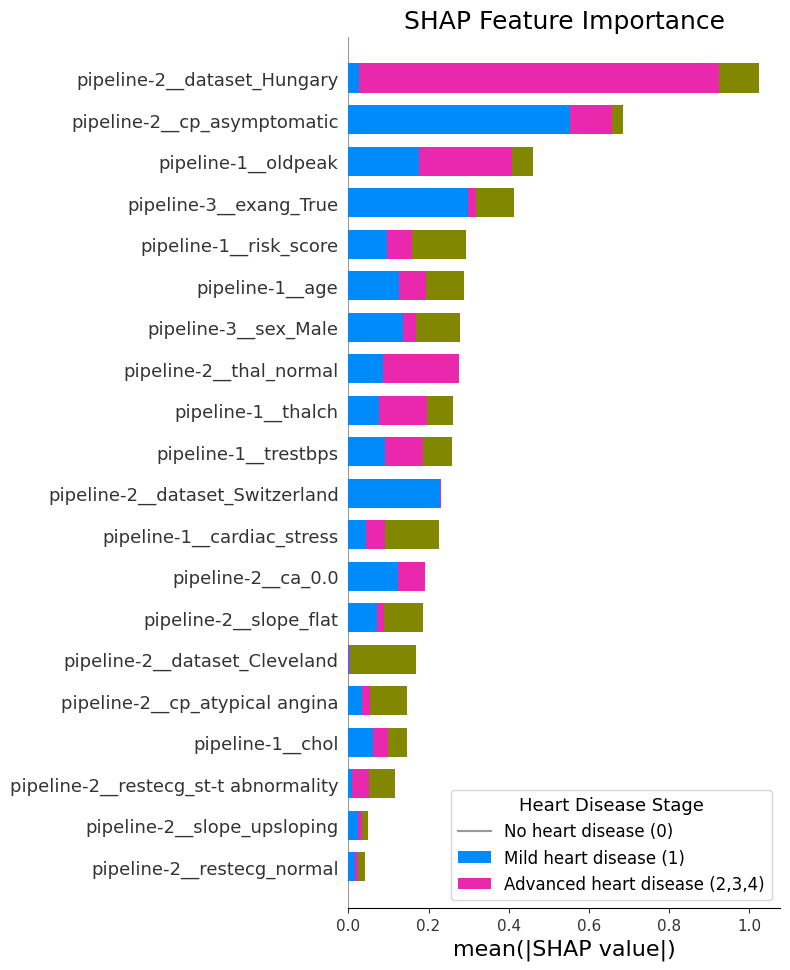

In [27]:
explainer = shap.TreeExplainer(model) # define the shap explainer
train_shap_values = explainer(X_train_enc) # train shap values
test_shap_values = explainer(X_test_enc) # test shap values
shap.summary_plot(train_shap_values, X_train_enc, plot_type="bar", show=False)
plt.title("SHAP Feature Importance", fontsize=18)
plt.xlabel("mean(|SHAP value|)", fontsize=16)

plt.legend(
    ["No heart disease (0)", "Mild heart disease (1)", "Advanced heart disease (2,3,4)"],
    title="Heart Disease Stage",
    fontsize=12,
    title_fontsize=13
)

plt.show()

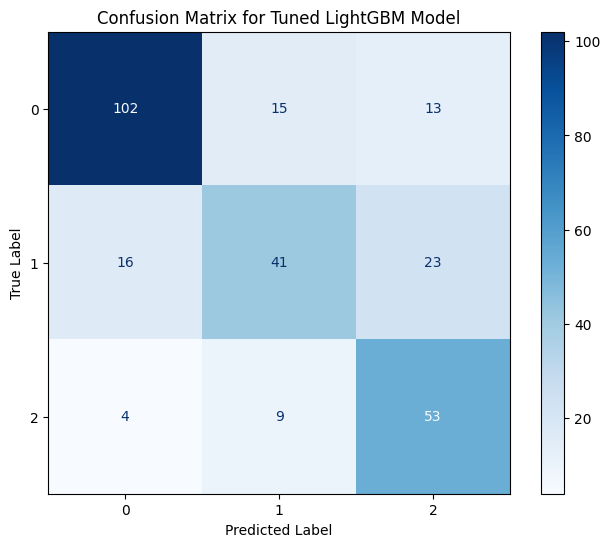

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_lgbm_model = random_search_lgbm.best_estimator_

# Make predictions on the test set
X_test = X_test.astype("category")
y_pred = best_lgbm_model.predict(X_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_lgbm_model.classes_)
display_cm.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Tuned LightGBM Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()